In [1]:
import warnings
warnings.filterwarnings("ignore")

# Week 4 Task: Machine Learning Model Development and Evaluation

**Project:** Breast Cancer Classification using Model Selection, Cross-Validation and Hyperparameter Tuning

**Objective:** Build, optimize and evaluate a reproducible classification model using a publicly available dataset.

## 1. Problem Statement
The goal is to classify observations as **malignant (0)** or **benign (1)** from numerical measurements computed from digitized images of breast-mass samples. This is a supervised binary-classification problem. The project emphasizes robust validation and transparent metric interpretation rather than accuracy alone.

## 2. Dataset and Source
The project uses the **Breast Cancer Wisconsin (Diagnostic)** dataset distributed through scikit-learn. It contains 569 observations and 30 numeric predictive features. The underlying dataset is publicly available through the UCI Machine Learning Repository.

**Public source:** https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

RANDOM_STATE = 42
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target_label'] = df['target'].map({0:'malignant', 1:'benign'})
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [3]:
print('Shape:', df.shape)
print('Target counts:')
print(df['target_label'].value_counts())
print('Missing values:', int(df.drop(columns=['target_label']).isna().sum().sum()))
print('Duplicate rows:', int(df.drop(columns=['target_label']).duplicated().sum()))

Shape: (569, 32)
Target counts:
target_label
benign       357
malignant    212
Name: count, dtype: int64
Missing values: 0
Duplicate rows: 0


In [4]:
df.describe().T[['count','mean','std','min','max']].head(10)

,count,mean,std,min,max
mean radius,569.0,14.127292,3.524049,6.98100,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.09744


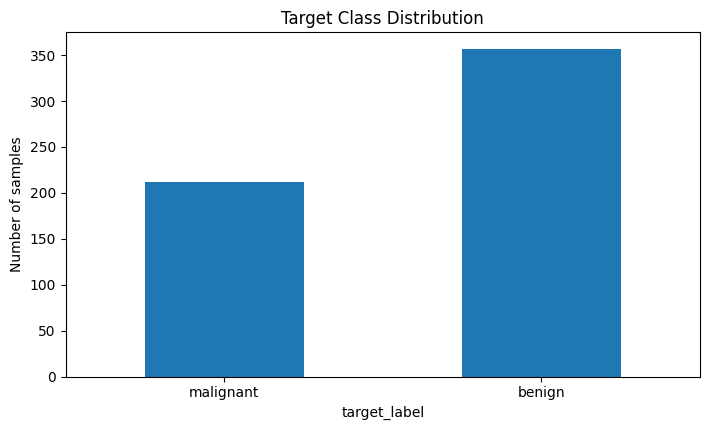

In [5]:
plt.figure(figsize=(7.2,4.4))
df['target_label'].value_counts().reindex(['malignant','benign']).plot(kind='bar')
plt.ylabel('Number of samples')
plt.title('Target Class Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocessing and Train/Test Split
A stratified **80/20 holdout split** is used with a fixed random seed for reproducibility. The test set is kept untouched during model selection and tuning. For algorithms sensitive to feature scale, `StandardScaler` is placed inside the pipeline, preventing data leakage during cross-validation.

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X = df.drop(columns=['target', 'target_label'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 455
Testing samples: 114


## 4. Algorithm Selection Strategy
Four common classifiers are compared: Logistic Regression, Decision Tree, Support Vector Machine (SVM), and Random Forest.

- **Logistic Regression:** strong linear baseline and easy to interpret; benefits from scaling.
- **Decision Tree:** captures nonlinear rules and is highly interpretable, but can overfit.
- **SVM:** effective for medium-sized, high-dimensional numeric datasets; scaling is important.
- **Random Forest:** captures nonlinear relationships and interactions while reducing single-tree variance.

The models are compared using the same 5-fold stratified cross-validation procedure. **F1-score** is used as the main selection criterion because it balances precision and recall; ROC-AUC is also reported as a complementary threshold-independent measure.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy':'accuracy','precision':'precision','recall':'recall','f1':'f1','roc_auc':'roc_auc'}

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True, random_state=RANDOM_STATE))]),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
}

rows=[]
for name, model in models.items():
    r = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'Model':name}
    for metric in scoring:
        row[metric.upper()] = r['test_'+metric].mean()
        row[metric.upper()+'_STD'] = r['test_'+metric].std()
    rows.append(row)
comparison = pd.DataFrame(rows).sort_values('F1', ascending=False)
comparison.round(4)

,Model,ACCURACY,ACCURACY_STD,PRECISION,PRECISION_STD,RECALL,RECALL_STD,F1,F1_STD,ROC_AUC,ROC_AUC_STD
0,Logistic Regression,0.9780,0.0098,0.9795,0.0162,0.9860,0.0131,0.9825,0.0078,0.9959,0.0050
2,SVM,0.9692,0.0146,0.9728,0.0225,0.9789,0.0131,0.9756,0.0113,0.9956,0.0048
3,Random Forest,0.9626,0.0179,0.9755,0.0172,0.9649,0.0248,0.9699,0.0146,0.9896,0.0083
1,Decision Tree,0.9165,0.0179,0.9528,0.0203,0.9123,0.0192,0.9319,0.0144,0.9179,0.0201


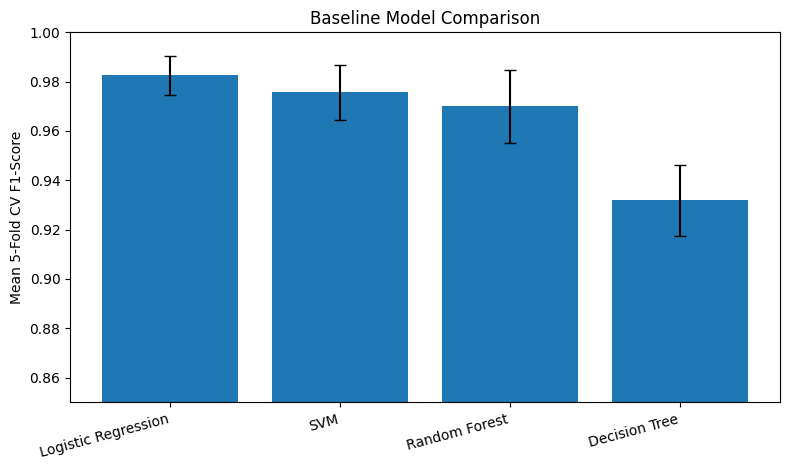

In [8]:
plt.figure(figsize=(8,4.8))
plt.bar(comparison['Model'], comparison['F1'], yerr=comparison['F1_STD'], capsize=4)
plt.ylabel('Mean 5-Fold CV F1-Score')
plt.ylim(0.85,1.0)
plt.title('Baseline Model Comparison')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 5. Cross-Validation and Hyperparameter Tuning
The leading baseline is tuned using `GridSearchCV`. The search is performed **only on the training set**, with the same 5-fold stratified cross-validation design.

For Logistic Regression, the main tunable parameter `C` controls regularization strength. Both L1 and L2 regularization are evaluated using the `liblinear` solver. The scaler and classifier remain inside a single pipeline so every fold learns scaling parameters only from its training portion.

In [9]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

grid = GridSearchCV(
    pipe, param_grid=param_grid, cv=cv, scoring='f1',
    n_jobs=-1, return_train_score=True
)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best mean CV F1:', round(grid.best_score_, 4))

Best parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best mean CV F1: 0.9861


In [10]:
grid_table = pd.DataFrame(grid.cv_results_).sort_values('rank_test_score')
grid_table[['param_model__C','param_model__penalty','mean_test_score','std_test_score','rank_test_score']].head(10).round(4)

,param_model__C,param_model__penalty,mean_test_score,std_test_score,rank_test_score
3,0.10,l2,0.9861,0.0043,1
5,1.00,l2,0.9842,0.0066,2
1,0.01,l2,0.9790,0.0089,3
4,1.00,l1,0.9719,0.0070,4
2,0.10,l1,0.9714,0.0147,5
7,10.00,l2,0.9705,0.0088,6
9,100.00,l2,0.9666,0.0116,7
8,100.00,l1,0.9630,0.0100,8
6,10.00,l1,0.9629,0.0154,9
0,0.01,l1,0.9328,0.0186,10


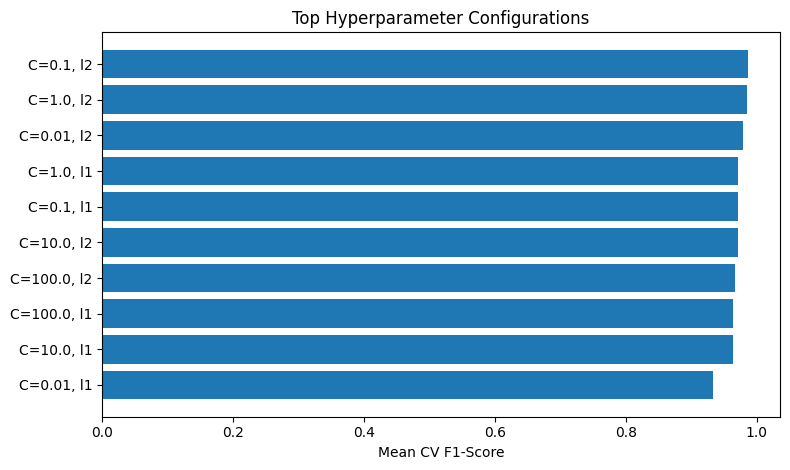

In [11]:
top = grid_table.head(10).iloc[::-1]
labels = [f"C={c}, {p}" for c,p in zip(top['param_model__C'], top['param_model__penalty'])]
plt.figure(figsize=(8,4.8))
plt.barh(range(len(top)), top['mean_test_score'])
plt.yticks(range(len(top)), labels)
plt.xlabel('Mean CV F1-Score')
plt.title('Top Hyperparameter Configurations')
plt.tight_layout()
plt.show()

## 6. Final Holdout Test Evaluation
After tuning, the selected estimator is refit on the complete training set by `GridSearchCV`, and the previously untouched test set is used once for final evaluation. We report accuracy, precision, recall, F1-score, ROC-AUC and a confusion matrix.

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

final_model = grid.best_estimator_
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1]

results = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
})
results.round(4)

Accuracy     0.9825
Precision    0.9861
Recall       0.9861
F1-Score     0.9861
ROC-AUC      0.9960
dtype: float64

In [13]:
print(classification_report(y_test, y_pred, target_names=['Malignant (0)','Benign (1)'], digits=4))

               precision    recall  f1-score   support

Malignant (0)     0.9762    0.9762    0.9762        42
   Benign (1)     0.9861    0.9861    0.9861        72

     accuracy                         0.9825       114
    macro avg     0.9812    0.9812    0.9812       114
 weighted avg     0.9825    0.9825    0.9825       114



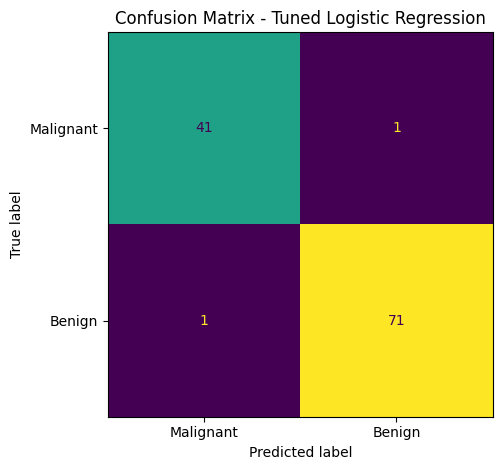

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant','Benign'])
disp.plot(values_format='d', colorbar=False)
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.tight_layout()
plt.show()

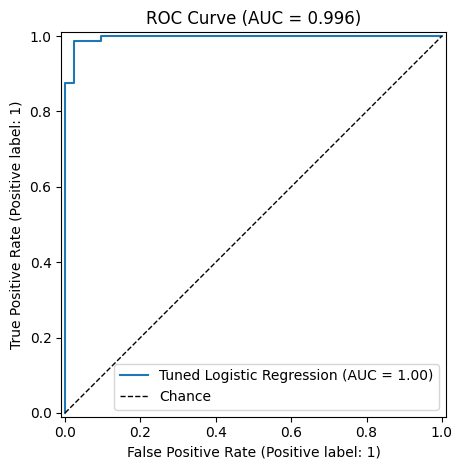

In [15]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob, name='Tuned Logistic Regression')
plt.plot([0,1],[0,1],'k--',linewidth=1,label='Chance')
plt.title(f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Feature Importance / Interpretability
For the final standardized Logistic Regression pipeline, coefficient magnitude indicates which standardized variables contribute most strongly to the decision function. The sign is model-specific: a positive coefficient increases the model's tendency toward class 1 (benign), while a negative coefficient moves it toward class 0 (malignant). These are statistical model associations, not causal medical relationships.

In [16]:
coef = final_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient':coef})
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Absolute_Coefficient', ascending=False)
coef_df.head(12)

,Feature,Coefficient,Absolute_Coefficient
21,worst texture,-0.548639,0.548639
20,worst radius,-0.515598,0.515598
27,worst concave points,-0.496777,0.496777
23,worst area,-0.495664,0.495664
22,worst perimeter,-0.472829,0.472829
10,radius error,-0.459034,0.459034
1,mean texture,-0.428021,0.428021
7,mean concave points,-0.413799,0.413799
13,area error,-0.409919,0.409919
28,worst symmetry,-0.405547,0.405547


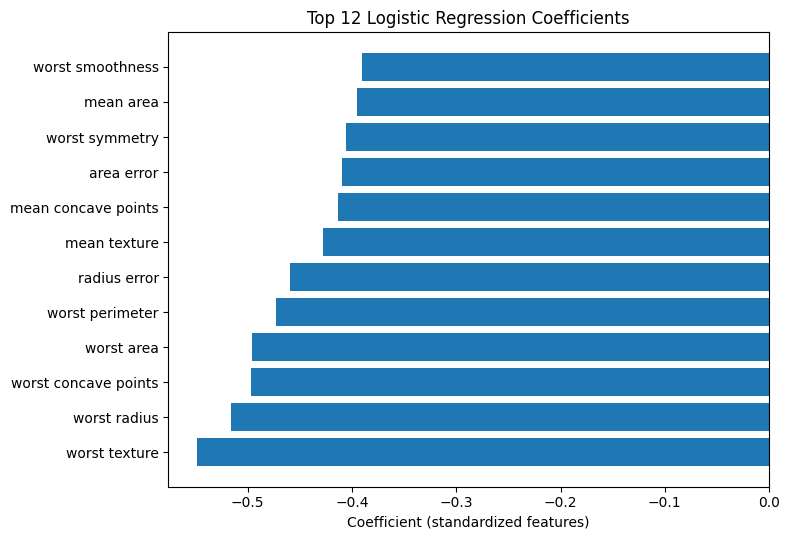

In [17]:
topcoef = coef_df.head(12).sort_values('Coefficient')
plt.figure(figsize=(8,5.5))
plt.barh(topcoef['Feature'], topcoef['Coefficient'])
plt.xlabel('Coefficient (standardized features)')
plt.title('Top 12 Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

## 8. Strengths and Weaknesses

**Strengths**
- Stratified cross-validation reduces dependence on one train/validation split.
- Hyperparameter tuning is performed without exposing the test set.
- Standardization is contained inside the pipeline, reducing leakage risk.
- Multiple complementary metrics are reported rather than relying on accuracy alone.
- Logistic Regression provides coefficient-based interpretability.

**Weaknesses**
- The model assumes a mostly linear relationship in the transformed feature space.
- The dataset is relatively small and is not representative of every clinical population or imaging workflow.
- A single holdout test split provides one estimate of generalization; external validation would be stronger.
- The dataset is a benchmark for educational modeling and should not be interpreted as a clinical diagnostic system.

## 9. Reproducibility Checklist
- Fixed random seed: `42`
- Stratified 80/20 train-test split
- 5-fold `StratifiedKFold` cross-validation
- Pipeline for scaling + model
- Explicit `GridSearchCV` parameter grid
- Test set used only for final evaluation
- Package versions can be captured in `requirements.txt`

## 10. Conclusion
This project demonstrates an end-to-end machine learning workflow: dataset selection, preprocessing, model comparison, cross-validation, hyperparameter optimization, holdout evaluation, interpretability and critical discussion of limitations. The final tuned model provides a reproducible benchmark on the selected public dataset, while the reported metrics show how predictive performance should be assessed from multiple perspectives.